# Draft

In [79]:
import glob
from pathlib import Path
import warnings

import ot
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import KMeans

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit, cross_val_score, LeaveOneOut
from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFECV, VarianceThreshold
from sklearn.decomposition import PCA

from src.repartition.data_loading import get_annotation, tif_to_real_mask
from src.repartition.data_analysis import *
from src.repartition.visualization import *
from src.repartition.constants import PROJECT_ROOT, PATH_PATIENT_DATA
from src.repartition.TissueCollection import * 

In [2]:
%load_ext autoreload
%autoreload 1
%aimport src.repartition.data_loading, src.repartition.data_analysis, src.repartition.visualization, src.repartition.constants, src.repartition.TissueCollection

## Load paths

In [3]:
project_root = PROJECT_ROOT
annot_dir = project_root / 'data/repartition/annotation/'
annotations_paths = glob.glob(str(annot_dir) + "/" +'*.tif')
annotations_paths = np.array(annotations_paths)
slides_annot = get_annotation(annotations_paths, tif_to_real_mask)

In [4]:
slides_tumor = get_tumor_slides(slides_annot)
#plot_slide_grid(slides_tumor)

In [5]:
distance_data, distribution_data_local = get_tissues_data(slides_annot, return_kde=True, local_ratio=True)
#_, distribution_data_global = get_tissues_data(slides_annot, return_kde=True, local_ratio=False)
#distance_data.to_csv('tissues_info.csv')

In [5]:
export_mask_pdf(
    slides_annot,
    output="masks.pdf"
)

In [8]:
export_furthest_tissue_pdf(
    slides_annot, 
    distance_data, 
    tissue_type='tumor',
    output="furthest_tumors.pdf",
    saveimg=True
)

In [174]:
all_tissue_areas = get_areas(distance_data)
export_tissues_proportion(
    all_tissue_areas, 
    draw_type='bar',
    saveimg=True
)

In [9]:
furthest_tum = get_furthest_tumors(distance_data, by='id-slide')
#furthest_tum.to_csv('furthest_tumors.csv')

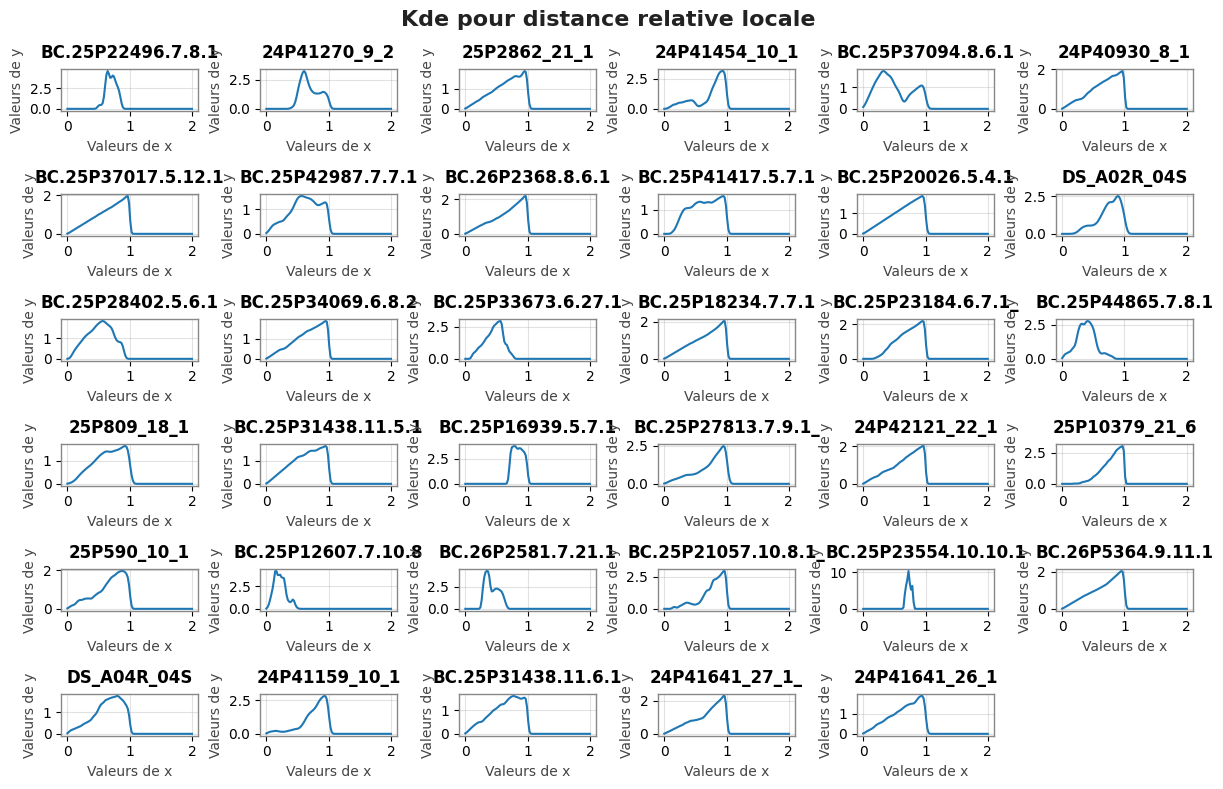

In [6]:
plot_distribution(distribution_data_local, show='kde', ref='center', suptitle="Kde pour distance relative locale")

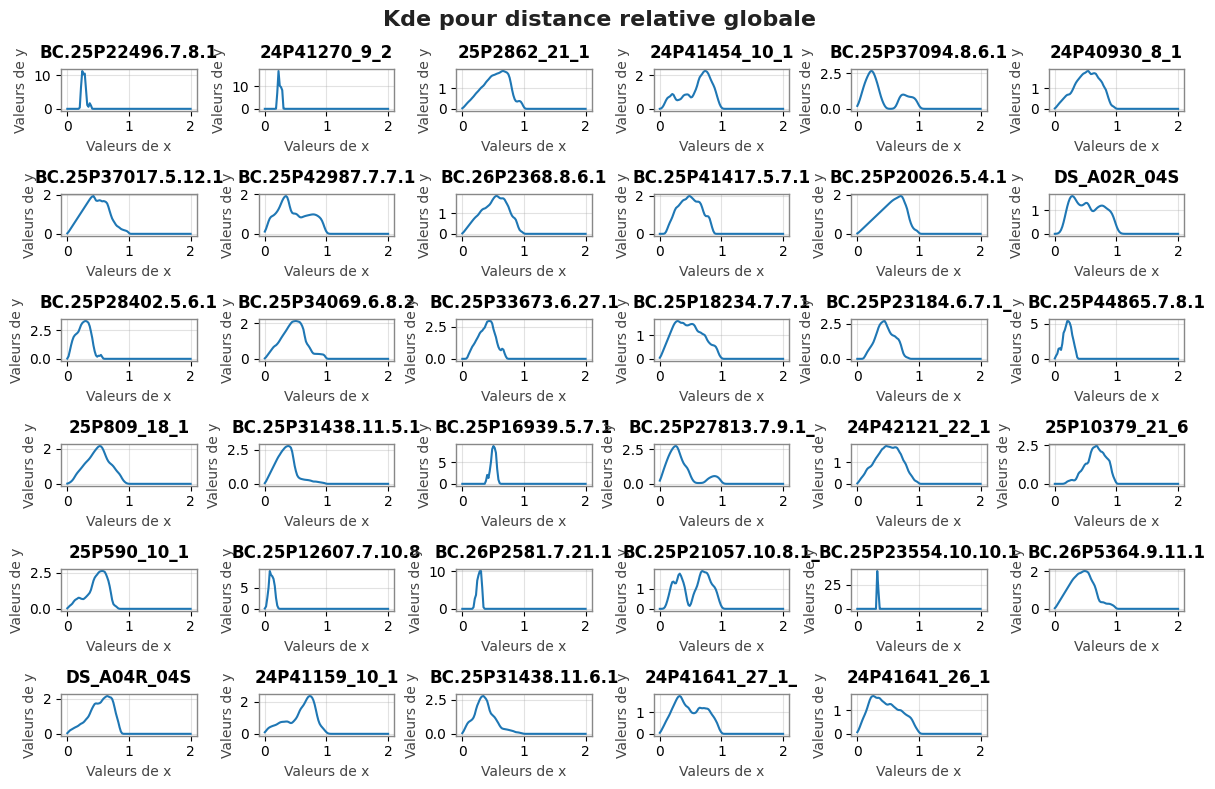

In [31]:
plot_distribution(distribution_data_global, show='kde', ref='center', suptitle="Kde pour distance relative globale")

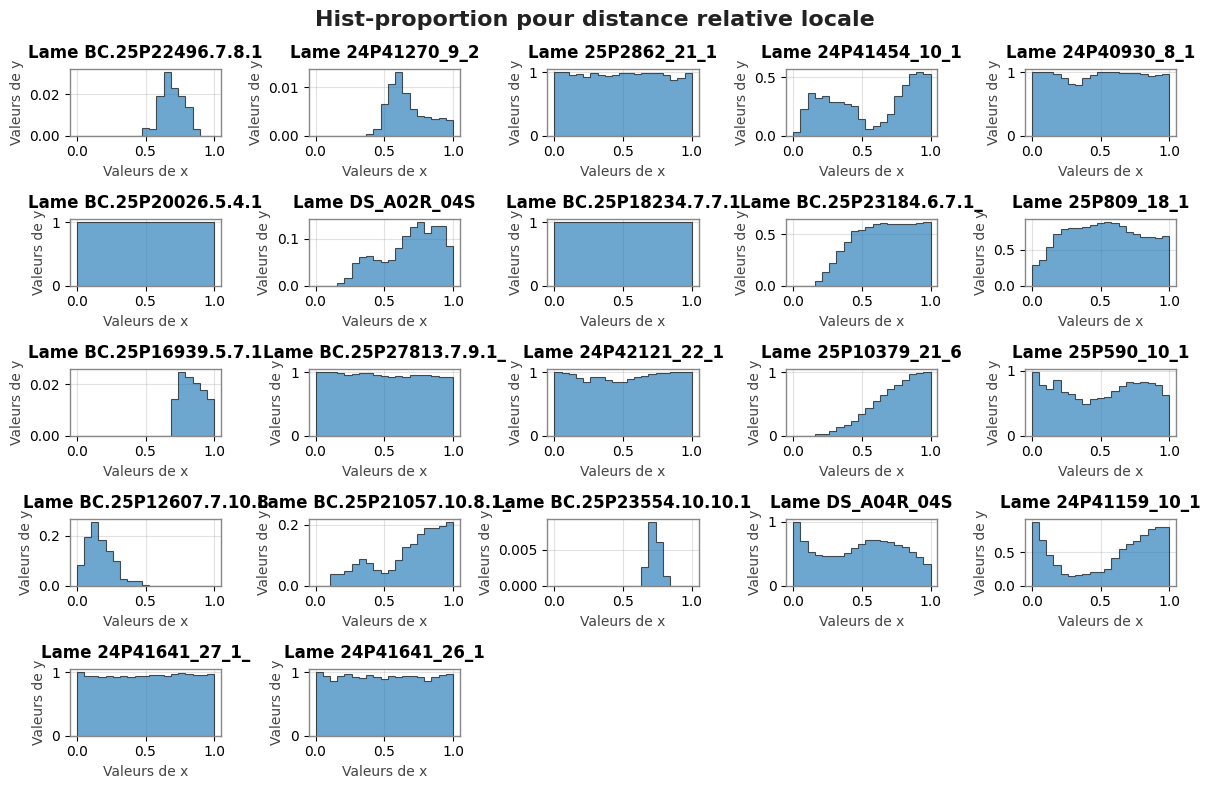

In [104]:
plot_distribution(distribution_data_local, show='hist-proportion', suptitle="Hist-proportion pour distance relative locale")

In [12]:
#feat2 = extract_features2(slides_annot, [0.2, 0.4, 0.6, 0.8, 1], distance_data)
feat2 = extract_features2(slides_annot, [0.1, 0.3, 0.6, 1], distance_data)

In [13]:
eval_points = np.linspace(0, 1, 50)
bins = np.linspace(0, 1, 20)
# [0.6, 0, 0.4] ou [0.5, 0, 0.5]
other_w = 0.5
weights = [1-other_w, 0.0, other_w]
kde_vec_local, hist_vec, other_feats = extract_features(
    distribution_data_local, eval_points, 
    bins, distance_data, slides_annot
)

""" kde_vec_global, hist_vec, other_feats = extract_features(distribution_data_global, eval_points, bins,
                                                distance_data=distance_data, slides_annot=slides_annot,
                                                only_distrib=False) """

""" dist_matrix1 = compute_distance_matrix(
    kde_vec_local, hist_vec, 
    weights, eval_points, bins, 
    additional_feats=feat2
) """

dist_matrix2 = compute_distance_matrix2(
    kde_vec_local, eval_points, 
    other_feats[:, 0],
    feat2
)

In [14]:
n_clusters = 1
dist_matrix = dist_matrix2
clustering = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='precomputed',
    linkage='average',           # 'ward' incompatible avec precomputed
)
labels_agglo = clustering.fit_predict(dist_matrix)

mds = MDS(n_components=2, metric='precomputed', random_state=42, n_init=1, init='classical_mds')
X_mds = mds.fit_transform(dist_matrix)

kmeans = KMeans(n_clusters=n_clusters, random_state=13, n_init="auto").fit(X_mds)
labels_kmeans = kmeans.predict(X_mds)


""" tsne = TSNE(n_components=2, metric='precomputed', random_state=42, perplexity=6, init=X_mds)
X_tsne = tsne.fit_transform(dist_matrix) """


" tsne = TSNE(n_components=2, metric='precomputed', random_state=42, perplexity=6, init=X_mds)\nX_tsne = tsne.fit_transform(dist_matrix) "

In [424]:
n_clusters = 2
clustering = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='euclidean',
    linkage='complete'
)
labels_agglo2 = clustering.fit_predict(feat2)

clustering = DBSCAN(eps=0.1, min_samples=1)
labels_dbscan2 = clustering.fit_predict(feat2)

kmeans = KMeans(n_clusters=n_clusters, random_state=13, n_init="auto").fit(feat2)
labels_kmeans2 = kmeans.predict(feat2)

mds = MDS(n_components=2, metric='euclidean', random_state=42, n_init=1, init='classical_mds')
X_mds2 = mds.fit_transform(feat2)

tsne = TSNE(n_components=2, metric='euclidean', random_state=42, perplexity=8, init='pca')
X_tsne2 = tsne.fit_transform(feat2)

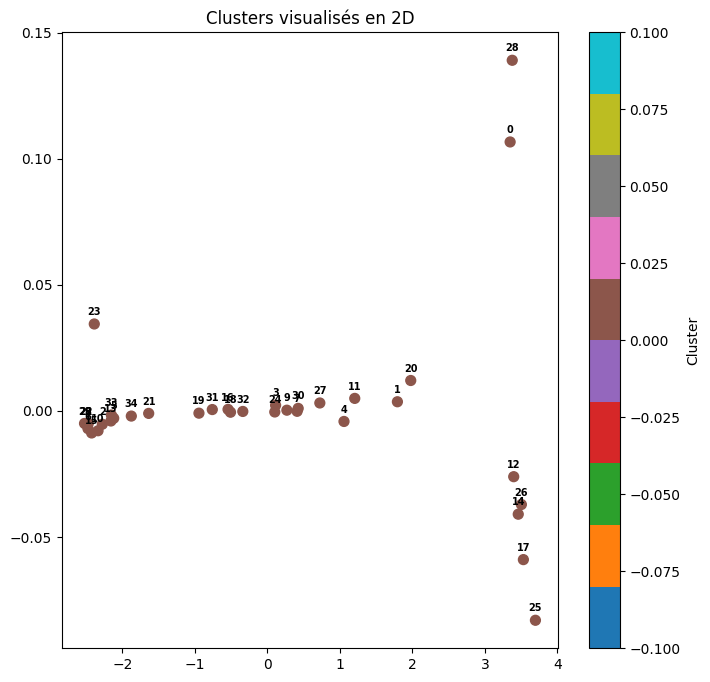

In [15]:
X = X_mds
labels = labels_agglo

fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=50)
plt.colorbar(scatter, label='Cluster')

for i, (x, y) in enumerate(X[:, :2]):
    ax.annotate(str(i), (x, y), fontsize=7, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

plt.title('Clusters visualisés en 2D')
plt.show()

In [16]:
clusters = get_slides_cluster(labels, slides_annot, slides_tumor)
clusters['cluster'].unique()

array([1, 0])

In [146]:
from bokeh.plotting import figure, output_notebook, show, reset_output
from bokeh.models import HoverTool, ColumnDataSource
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from bokeh.embed import file_html
from bokeh.resources import CDN
import base64
from bokeh.plotting import figure, output_notebook, show, output_file, save
from bokeh.models import HoverTool, ColumnDataSource, LinearColorMapper, Legend
from bokeh.palettes import Category10_10, Inferno256 

In [ ]:
def composite_to_base64_transparent(composite_img, tolerance=20):
    """
    Prend l'image composite NumPy, rend le fond blanc transparent,
    et encode en Base64 PNG pour Bokeh.
    """
    # 1. Conversion en format compatible OpenCV (0-255, uint8)
    # Assumons que make_composite retourne des floats 0-1
    img_uint8 = (composite_img * 255).astype(np.uint8)
    
    # 2. Conversion RGB (Matplotlib) -> BGRA (OpenCV + Alpha)
    img_bgra = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGRA)
    
    # 3. Transparence : Masque pour le fond "presque blanc"
    lower_white = 255 - tolerance
    bg_mask = (img_bgra[:, :, 0] >= lower_white) & \
              (img_bgra[:, :, 1] >= lower_white) & \
              (img_bgra[:, :, 2] >= lower_white)
    
    img_bgra[bg_mask, 3] = 0  # Canal Alpha à 0 (transparent)
    
    # 4. Redimensionnement pour la performance de l'infobulle (optionnel)
    img_bgra = cv2.resize(img_bgra, (200, 200), interpolation=cv2.INTER_AREA)

    # 5. Encodage en PNG Base64
    _, buffer = cv2.imencode('.png', img_bgra)
    b64_string = base64.b64encode(buffer).decode('utf-8')
    
    return f"data:image/png;base64,{b64_string}"

# A. Génération des images composites et conversion Base64
b64_images = []
for sld in slides_tumor:
    masks_dict = sld[1]
    composite = make_composite(masks_dict)
    b64 = composite_to_base64_transparent(composite, tolerance=30)
    b64_images.append(b64)

# C. Création du DataFrame
df = pd.DataFrame({
    'x': X[:, 0],
    'y': X[:, 1],
    'cluster': labels,
    'cluster_str': labels.astype(str), # Bokeh préfère les chaînes pour les couleurs catégorielles
    'img_data': b64_images
})

# --- 4. Visualisation Bokeh ---

reset_output()
output_notebook()
datasource = ColumnDataSource(df)

# Configuration de la coloration par cluster
# Utilisez Category10_10 si vous avez < 10 clusters, sinon Inferno256
unique_clusters = df['cluster_str'].unique()
palette = Category10_10 if len(unique_clusters) <= 10 else Inferno256
color_mapper = LinearColorMapper(palette=palette, low=df['cluster'].min(), high=df['cluster'].max())

plot = figure(
    title="Visualisation des Clusters d'Images",
    tools="pan,wheel_zoom,reset,box_zoom,save",
    width=1050,
    height=700,
    background_fill_color="#fafafa"
)

# Dessiner les points (colorés par cluster)
scatter = plot.scatter(
    'x', 'y', 
    source=datasource, 
    size=10, 
    alpha=0.7, 
    # Coloration dynamique :
    fill_color={'field': 'cluster', 'transform': color_mapper},
    line_color=None,
    legend_field='cluster_str',
)

legend = plot.legend[0]
plot.add_layout(legend, 'right')
legend.title = 'Clusters'
legend.click_policy = 'hide'

# Configuration de l'infobulle HTML (avec transparence)
hover = HoverTool(tooltips="""
    <div style="background-color: rgba(255, 255, 255, 0.9); padding: 10px; border-radius: 8px; border: 1px solid #ccc;">
        <div><strong>Cluster:</strong> @cluster</div>
        <div style="margin-top: 5px;">
            <img src="@img_data" alt="Composite preview" style="max-width: 200px; max-height: 200px; display: block; border: 1px solid #eee;">
        </div>
    </div>
""")

plot.add_tools(hover)
show(plot)

html_content = file_html(plot, CDN, "Visualisation des clusters d'images")
with open("interactive_clusters.html", "w", encoding="utf-8") as f:
    f.write(html_content)



Loading BokehJS ...

' output_file("interactive_clusters.html", title="Visualisation des clusters d\'images")\nsave(plot) '

In [34]:
def plot_cluster_grid(slides_tumor, cluster_labels):
    unique_labels = np.unique(cluster_labels)

    for l in unique_labels:
        cluster_slides = [sld for sld, label in zip(slides_tumor, cluster_labels)
                        if label==l]
        plot_slide_grid(cluster_slides, figsize=(8,8), title=f"cluster-{l}")

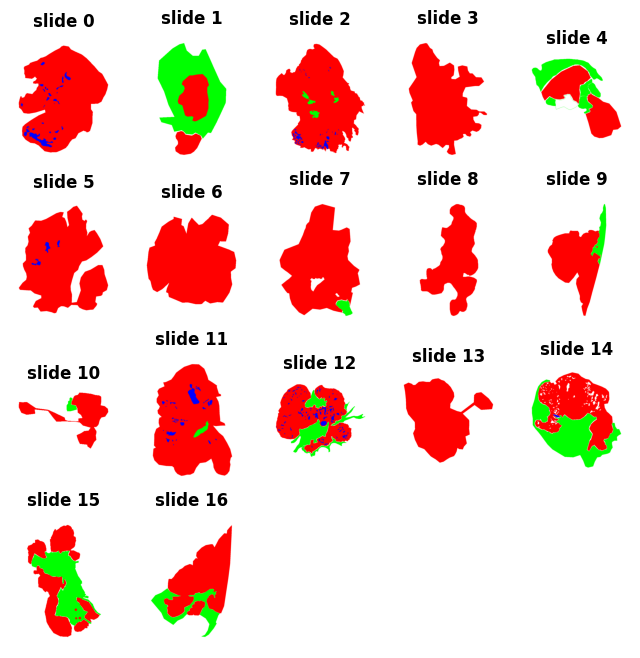

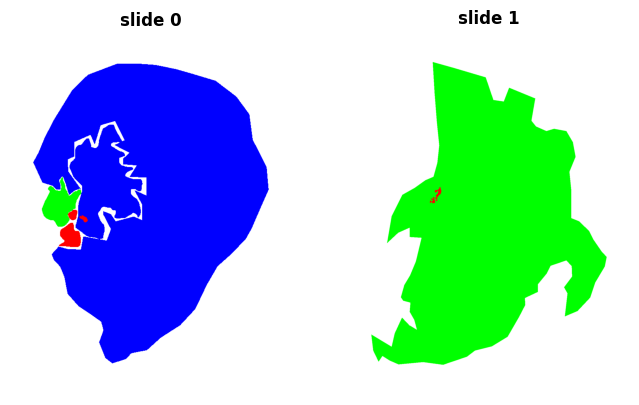

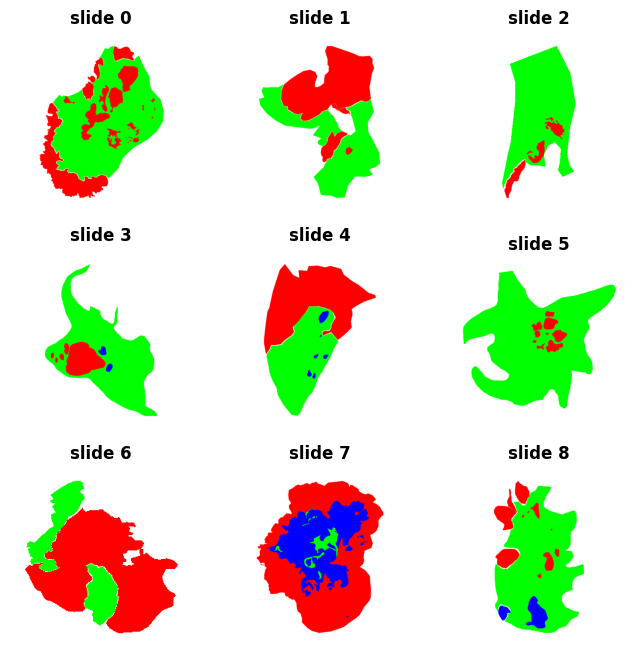

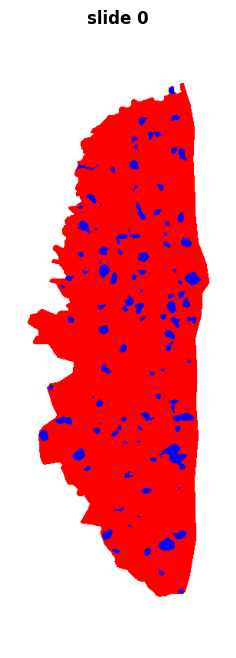

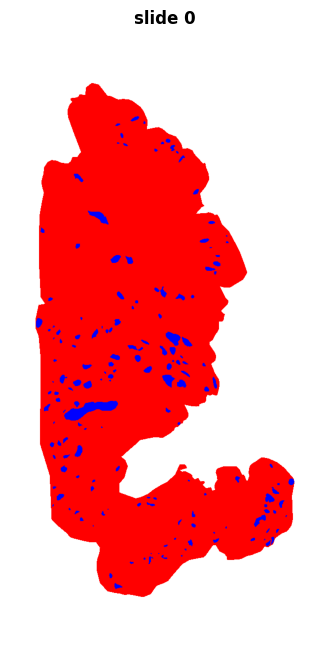

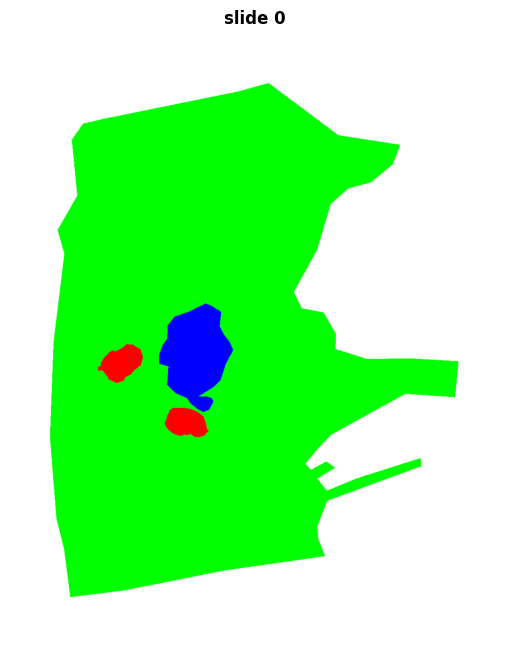

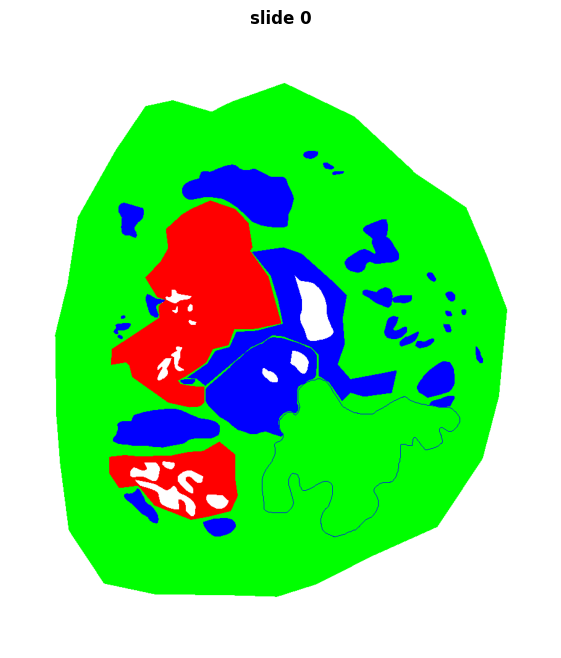

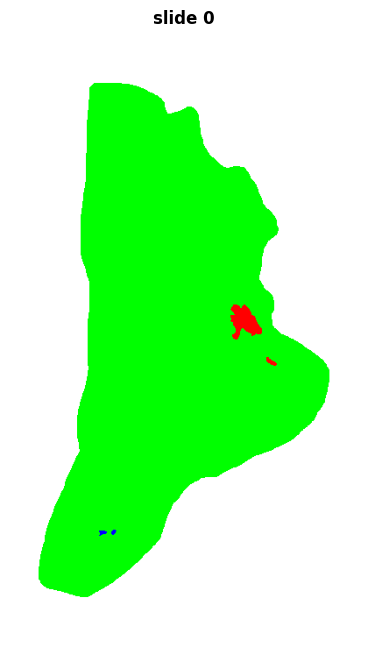

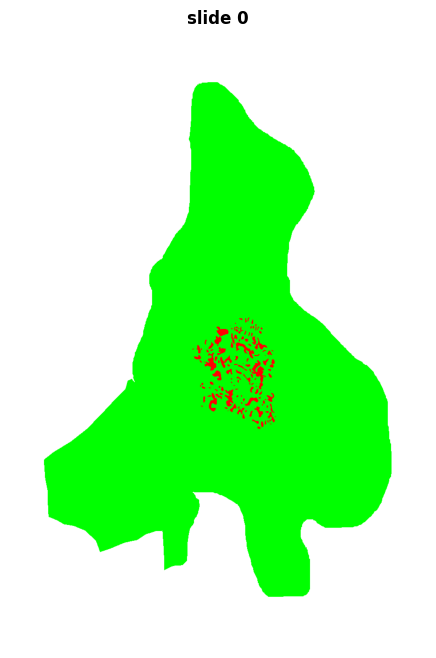

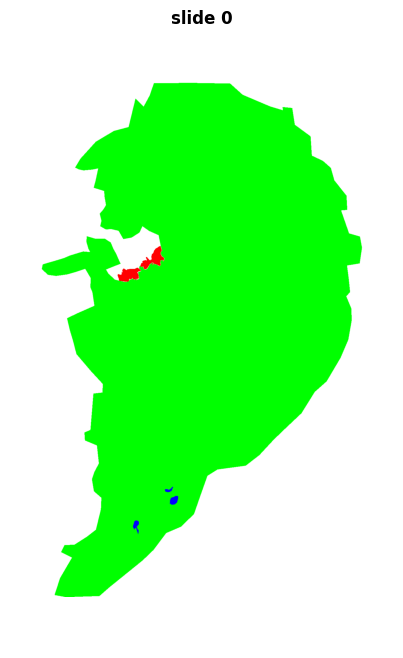

In [41]:
plot_cluster_grid(slides_tumor, labels)

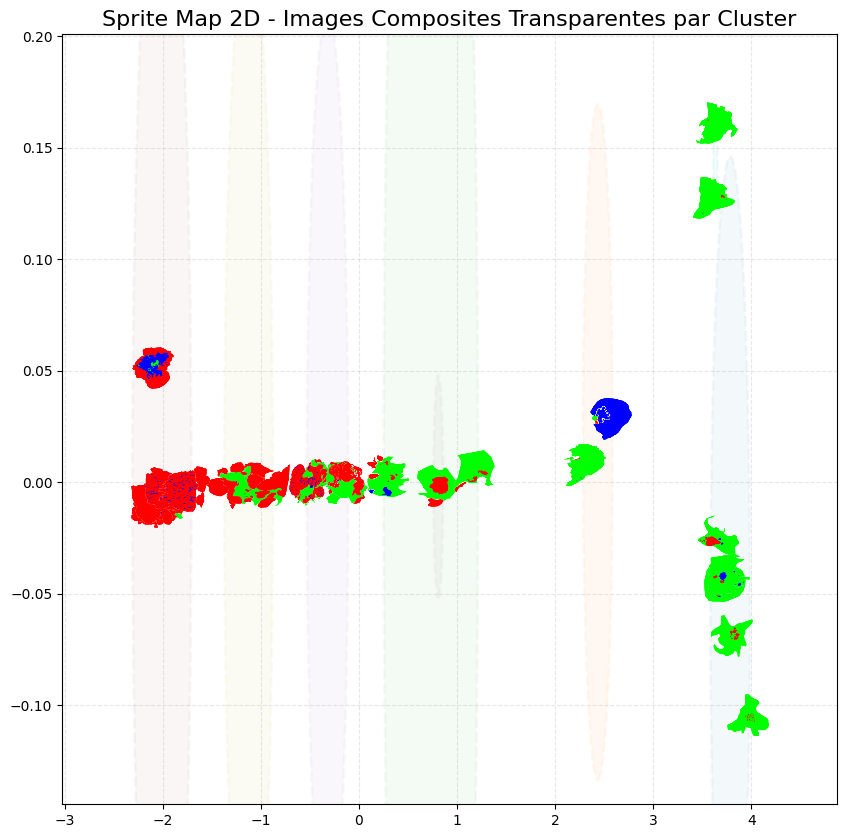

In [249]:
from matplotlib.patches import Circle

def prepare_sprite_image(composite_img, cluster_color, tolerance=30, target_size=(100, 100)):
    img_uint8 = (composite_img * 255).astype(np.uint8)
    img_rgba = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2RGBA)
    
    # Transparence du fond
    lower_white = 255 - tolerance
    bg_mask = (img_rgba[:, :, 0] >= lower_white) & \
              (img_rgba[:, :, 1] >= lower_white) & \
              (img_rgba[:, :, 2] >= lower_white)
    object_mask = ~bg_mask
    
    # On trouve les coordonnées (lignes, colonnes) de tous les pixels non-blancs
    coords = np.argwhere(object_mask)
    
    # Si l'image n'est pas entièrement blanche, on la recadre
    if len(coords) > 0:
        # y_min, x_min = coordonnées minimales / y_max, x_max = coordonnées maximales
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        
        
        # On extrait uniquement la zone contenant l'objet (l'image est "croppée")
        img_rgba = img_rgba[y_min:y_max+1, x_min:x_max+1]
        
        # On doit aussi recalculer le masque de fond pour cette zone recadrée
        bg_mask = bg_mask[y_min:y_max+1, x_min:x_max+1]
    # ----------------------------------

    # 3. Application de la transparence sur la zone recadrée
    img_rgba[bg_mask, 3] = 0
    
    # 4. Redimensionnement strict (l'objet prend maintenant TOUTE la place dans le carré)
    img_rgba = cv2.resize(img_rgba, target_size, interpolation=cv2.INTER_AREA)

    
    return img_rgba

# --- 2. Fonction principale avec Séparation et Gestion du Zoom ---

def plot_sprites_2d_advanced(X_2d, list_of_masks, clusters, zoom=0.5, figsize=(10,10)):

    fig, ax = plt.subplots(figsize=figsize, facecolor='#ffffff')
    
    unique_clusters = sorted(list(set(clusters)))
    cmap = plt.get_cmap('tab10', len(unique_clusters))
    
    cluster_to_color = {}
    for i, cl in enumerate(unique_clusters):
        r, g, b, a = cmap(i)
        cluster_to_color[cl] = (int(r*255), int(g*255), int(b*255), 255)
    
    # 2. SIMULATION DU PAD (set_xlim / set_ylim automatique)
    x_min, x_max = X_2d[:, 0].min(), X_2d[:, 0].max()
    y_min, y_max = X_2d[:, 1].min(), X_2d[:, 1].max()
    
    # Calcul des marges (pad) proportionnelles à la taille du graphique (15% de marge)
    x_pad = (x_max - x_min) * 0.15
    y_pad = (y_max - y_min) * 0.15
    
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    for cl in unique_clusters:
        cluster_points = X_2d[clusters == cl]
        centroid = cluster_points.mean(axis=0)
        radius = np.max(np.linalg.norm(cluster_points - centroid, axis=1)) * 1.1
        radius = 0.05 if radius == 0 else radius
        circle = Circle(centroid, radius, color=np.array(cluster_to_color[cl])/255.0, alpha=0.05, linestyle='--', linewidth=2)
        ax.add_patch(circle)

    for i in range(len(X_2d)):
        x, y = X_2d[i, 0], X_2d[i, 1]
        cl = clusters[i]
        
        composite = make_composite(list_of_masks[i])
        color_rgba = cluster_to_color[cl]
        
        sprite = prepare_sprite_image(composite, color_rgba, target_size=(100, 100))
        
        imagebox = OffsetImage(sprite, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)

    
    ax.set_title("Sprite Map 2D - Images Composites Transparentes par Cluster", fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

plot_sprites_2d_advanced(X, slides_tumor, labels, zoom=0.3, figsize=(10, 10))

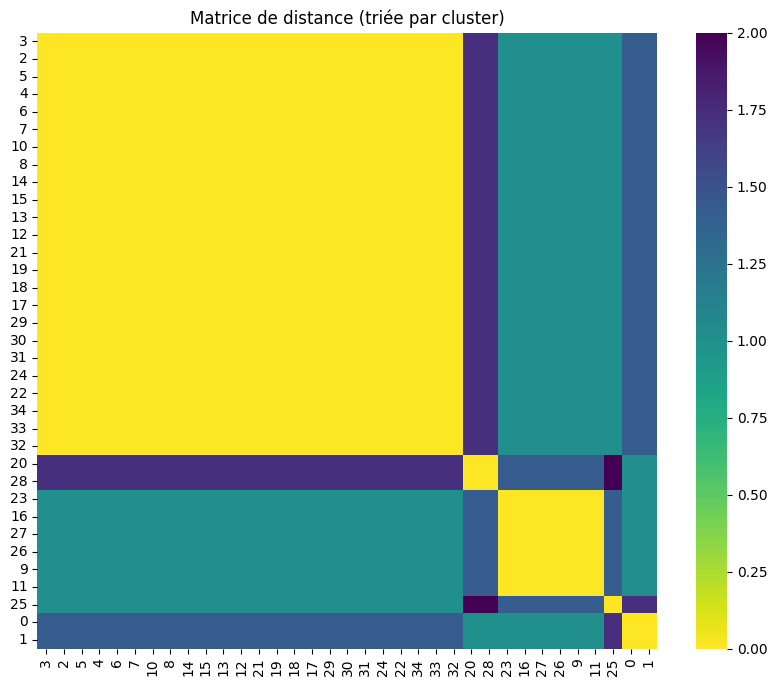

In [109]:
order = np.argsort(labels)
plt.figure(figsize=(10, 8))
sns.heatmap(
    dist_matrix[order][:, order],
    cmap='viridis_r',
    xticklabels=order,
    yticklabels=order,
)
plt.title('Matrice de distance (triée par cluster)')

plt.show()

In [251]:
mds.stress_

np.float64(336.0237870913599)

In [ ]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [ ]:
plot_dendrogram(clustering, truncate_mode="level", p=6)

In [ ]:
dist_2d = pairwise_distances(X)

orig = dist_matrix
proj = mds.dissimilarity_matrix_

plt.scatter(orig, proj, alpha=0.5)
plt.plot([orig.min(), orig.max()], [orig.min(), orig.max()], 'r--')
plt.xlabel("Distances originales")
plt.ylabel("Distances projetées")
plt.title("Shepard plot — idéalement tous les points sur la diagonale")

In [136]:
score = silhouette_score(dist_matrix, labels_agglo, metric='precomputed')
print(f"Silhouette : {score:.3f}")  # Entre -1 et 1, > 0.5 = bons clusters

Silhouette : 0.447


# Processing patient data

### Loading

In [116]:
raw_data = pd.read_excel(PATH_PATIENT_DATA)

vars_clust = (
    'Patient',
    #'Sexe',
    #'Tabagisme avant le diagnostic (oui/jamais)',
    'Age au diagnostic',                                          #num
    #'Taille tumorale avant TTT (en mm)',
    #'Type histologique',
    'Stade clinique',
    'PDL1',                                                       #num
    #'cTNM',
    #'Type de TTT neoadjuvant',
    #'Molecule n°1',
    'Molecule n°2',
    #'Molecule n°3',
    #'Nombre de cycle de chimio-immunothérapie',                   #num
    #'Nombre de cycle de maintenance',                             #num
    #'Delai entre dernier TTT et chirurgie (en j)',
)

vars_desc = (
    'Patient',
    'Type histologique',
    'Stade clinique',
    'Type de chirurgie', 
    'Regression pathologique'
)

data_c = raw_data.loc[:, vars_clust]
data_d = raw_data.loc[:, vars_desc]

### Data cleaning

In [118]:
def clean_data_clust(df):
    clean_df = df.copy()
    dropped_samples = 0

    clean_df['Patient'] = clean_df['Patient'].str.strip()
    patient_indices = clean_df['Patient'].dropna().index
    clean_df = clean_df.iloc[patient_indices, :]

    missing_val_feats = [
        #'Tabagisme avant le diagnostic (oui/jamais)',
        'Age au diagnostic',
        #'Molecule n°1',

    ]
    for col in missing_val_feats:
        missing_val = clean_df[col] == '.'
        clean_df.drop(clean_df.index[missing_val], inplace=True)
        print(f"Cleaning... {col}")
        print(f"Drop samples = {np.sum(missing_val)}")
        dropped_samples += np.sum(missing_val)

    missing_val_feats2 = [
        #'Nombre de cycle de chimio-immunothérapie',
        'Stade clinique',
    ]
    for col in missing_val_feats2:
        missing_val = pd.to_numeric(
            clean_df[col], errors='coerce'
        ).isna()
        clean_df.drop(clean_df.index[missing_val], inplace=True)
        print(f"Cleaning... {col}")
        print(f"Drop samples = {np.sum(missing_val)}")
        dropped_samples += np.sum(missing_val)

    missing_val_molecules = [
        'Molecule n°2',
        #'Molecule n°3'
    ]
    for col in missing_val_molecules:
        empty_val = clean_df[col] == '.'
        clean_df.loc[empty_val, col] = -1 # new label when the molecule is not used.
        clean_df.loc[:, col] += 1
    
    """ empty_val = clean_df['Nombre de cycle de maintenance'] == '.'
    clean_df.loc[empty_val, 'Nombre de cycle de maintenance'] = 0 """

    clean_df.reset_index(inplace=True, drop=True)

    vars_num = [
        'Age au diagnostic',
        'PDL1', 
        #'Nombre de cycle de chimio-immunothérapie', 
        #'Nombre de cycle de maintenance'
    ]
    vars_cat = [v for v in clean_df.columns if v not in vars_num]

    clean_df[vars_cat] = clean_df[vars_cat].astype('object') #or category ?

    for col in vars_num:
        clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

    print(f"\nTotal dropped samples = {dropped_samples}")

    return clean_df

def clean_data_desc(clean_df):
    pass

In [119]:
new_data_c = clean_data_clust(data_c)
new_data_c = new_data_c.merge(clusters, how='inner', left_on='Patient', right_on='id-patient')
new_data_c.drop(labels=['Patient', 'id-patient'], axis=1, inplace=True)

X_raw = new_data_c.loc[:, new_data_c.columns[:-1]]
y = new_data_c.loc[:, 'cluster'].to_numpy()
print(f"X_raw shape : {X_raw.shape}")

vars_num = [
        'Age au diagnostic',
        'PDL1', 
        #'Nombre de cycle de chimio-immunothérapie', 
        #'Nombre de cycle de maintenance'
]
vars_cat = [v for v in X_raw.columns if v not in vars_num]

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), vars_num),
    ('cat', OneHotEncoder(drop='first'), vars_cat),
])
X = preprocessor.fit_transform(X_raw)
X = VarianceThreshold(threshold=0.0).fit_transform(X)
feats_name = preprocessor.get_feature_names_out()
print(f"X shape : {X.shape}")


X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.3, stratify=y)

Cleaning... Age au diagnostic
Drop samples = 1
Cleaning... Stade clinique
Drop samples = 10

Total dropped samples = 11
X_raw shape : (48, 4)
X shape : (48, 8)


### Data analysis

In [113]:
classes, counts = np.unique(y, return_counts=True)
for cls, c in zip(classes, counts):
    print(f"Classe {cls}: {c} samples")

Classe 0: 24 samples
Classe 1: 38 samples


/home/jaffolabi/Documents/lung_map/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jaffolabi/Documents/lung_map/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


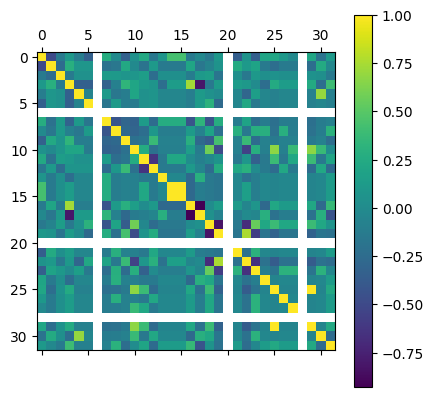

In [53]:
corr = np.corrcoef(X_train.toarray(), y_train, rowvar=False)
plt.matshow(corr)
plt.colorbar();

In [433]:
corr_strength = np.abs(corr[-1, :-1])
indices = np.argsort(corr_strength)[::-1]
k = 5
print(f"Top {k} strongest correlated features")
for i in range(k):
    print(f"{i+1}. {feats_name[indices[i]]}, corr = {corr_strength[indices[i]]:.2f}")

Top 5 strongest correlated features
1. cat__Molecule n°2_2, corr = 0.36
2. cat__Molecule n°2_1, corr = 0.30
3. cat__Type histologique_2.0, corr = 0.26
4. cat__Molecule n°3_2, corr = 0.25
5. cat__Type histologique_1.0, corr = 0.22


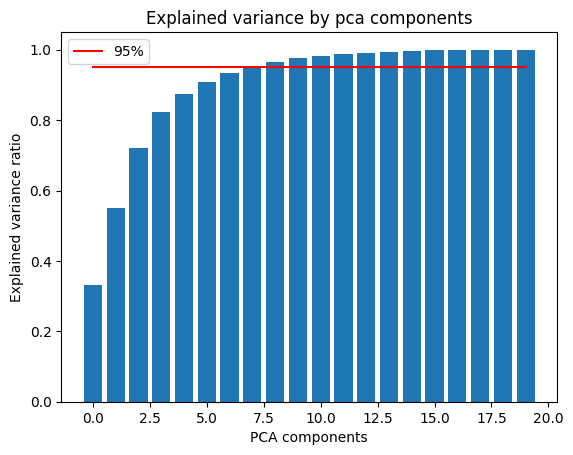

In [ ]:
pca = PCA().fit(X)
plt.bar(np.arange(pca.n_components_), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.arange(pca.n_components_), np.ones(pca.n_components_)*0.95, c='red', label='95%')
plt.legend()

plt.xlabel('PCA components')
plt.ylabel('Explained variance ratio')
plt.title('Explained variance by pca components')

In [352]:
k = 7
X_pca = PCA(n_components=k).fit_transform(X)

__Analyse__:
En utilisant les axes issus de l'ACP on n'obtient pas un meilleur score de classification (f1_macro ~ 0.67)

In [410]:
import textwrap

In [39]:
def plot_feat_distribution(X, y, figsize=None):
    _, n_feats = X.shape
    """ cols = math.ceil(math.sqrt(n_feats))
    rows = math.ceil(n_feats / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).flatten() if n_feats > 1 else [axes] """
    if figsize:
        plt.figure(figsize=figsize)
    i = 1
    for c in range(2):
        for col in X:
            vals, counts = np.unique(X[y==c][col], return_counts=True)
            plt.subplot(2, n_feats, i)
            #plt.bar(vals, counts)
            plt.hist(X[y==c][col])
            plt.xlabel("Values")
            plt.ylabel("Counts")
            title = textwrap.fill(f"{col}(y={c})", width=25)
            plt.title(title)
            i += 1
    """ plt.subplots_adjust(
        left=0.1, bottom=0.1, right=1, 
        top=0.9, wspace=0.4,hspace=0.4
    ) """
    plt.tight_layout()
    plt.suptitle("Distribution des variables", y=1.1)


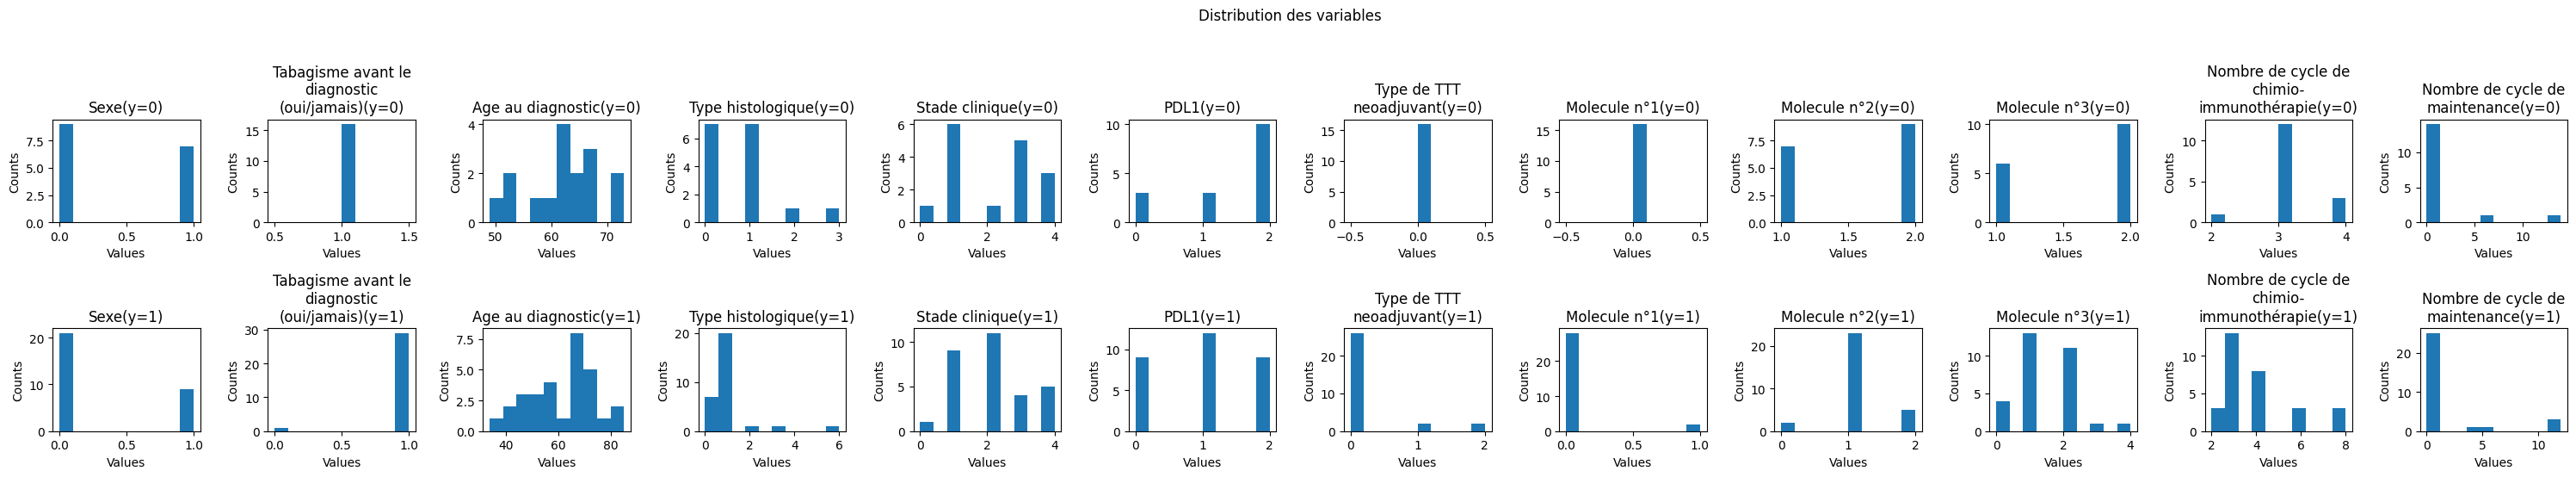

In [54]:
plot_feat_distribution(X_raw, y, figsize=(30,5))

__Analyse__:  
Il y a des variables dont la distribution reste la même quelque soit la classe :  
- Sexe, Tabagisme, PDL1, Type de TTT neoadjuvant, Molecule n°1, nb cycle de maintenance

In [55]:
def get_class_weight(y, norm=True, square_root=True):
    labels, label_count = np.unique(y, return_counts=True)
    total_pxl = np.sum(label_count)
    freq = {int(l): count/total_pxl for l, count in zip(labels, label_count)}
    inv_feq = {int(l): 1/freq[l] for l in labels}
    if norm:
        if square_root:
            weights = {l: np.sqrt(i)/np.sqrt(list(inv_feq.values())).mean()
                       for l, i in inv_feq.items()}
        else:
            weights = {l: i/np.array(list(inv_feq.values())).mean()
                       for l, i in inv_feq.items()}
    else:
        weights = inv_feq
    return weights

In [121]:
weights = get_class_weight(y_train, square_root=False)
weights

{0: np.float64(1.3333333333333333), 1: np.float64(0.6666666666666666)}

In [134]:
rf = RandomForestClassifier(n_estimators=100, random_state=0, class_weight=weights)
gb = GradientBoostingClassifier(
    n_estimators=100,
    loss='log_loss',
    random_state=11,
)

In [135]:
clf = rf
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf.fit(X_train, y_train)
    
    prediction = clf.predict(X_test)
    
    y_true.append(y_test[0])
    y_pred.append(prediction[0])

print(classification_report(y_true, y_pred, zero_division=np.nan))

              precision    recall  f1-score   support

           0       0.83      0.62      0.71        16
           1       0.83      0.94      0.88        32

    accuracy                           0.83        48
   macro avg       0.83      0.78      0.80        48
weighted avg       0.83      0.83      0.83        48



In [127]:
clf.feature_importances_

array([0.40060853, 0.17006557, 0.04893842, 0.10400102, 0.04780428,
       0.03101884, 0.06636114, 0.13120219])

In [ ]:
def feat_selection(X, y, X_train, y_train, feats_name, selector='SelectKBest'):
    n_feats = X.shape[1]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
    rf = RandomForestClassifier(n_estimators=100, random_state=11)
    gb = GradientBoostingClassifier(
        n_estimators=100,
        loss='log_loss',
        random_state=11,
    )
    clf = rf

    if selector.lower() == 'SelectKBest'.lower():
        means = []
        stds = []
        all_selection = []
        for k in range(1, n_feats+1):
            s = SelectKBest(f_classif, k=k)
            with warnings.catch_warnings(), np.errstate(divide='ignore', invalid='ignore'):
                warnings.simplefilter("ignore")
                s.fit(X, y)
                feats_selected = s.get_support()
                scores = cross_val_score(clf, X[:, feats_selected], y, cv=cv, scoring='f1_macro')
            means.append(scores.mean())
            stds.append(scores.std())
            all_selection.append(feats_selected)

        plt.errorbar(np.arange(1, n_feats+1, 1), means, stds)
        idx_best = np.argmax(means)
        print(f"Best selection : {feats_name[all_selection[idx_best]]} \n k = {len(feats_name[all_selection[idx_best]])} \n f1_macro = {means[idx_best]}")

    elif selector.lower() == 'RFECV'.lower():
        with warnings.catch_warnings(), np.errstate(divide='ignore', invalid='ignore'):
            warnings.simplefilter("ignore")
            s = RFECV(clf, cv=cv, scoring='f1_macro')
            s.fit(X, y)
        means = s.cv_results_['mean_test_score']
        stds = s.cv_results_['std_test_score']
        plt.errorbar(s.cv_results_['n_features'], means, stds)
        idx_best = np.argmax(means)
        print(f"Best selection : {feats_name[s.support_]} \n k = {len(feats_name[s.support_])} \n f1_macro = {means.max()}")
    else:
        return None
    plt.xlabel('k best features')
    plt.ylabel('f1_macro')
    plt.title('k best features evaluation')
    plt.grid()
    plt.show()


Best selection : ['cat__Stade clinique_2' 'cat__Molecule n°2_2'] 
 k = 2 
 f1_macro = 0.7704395604395604


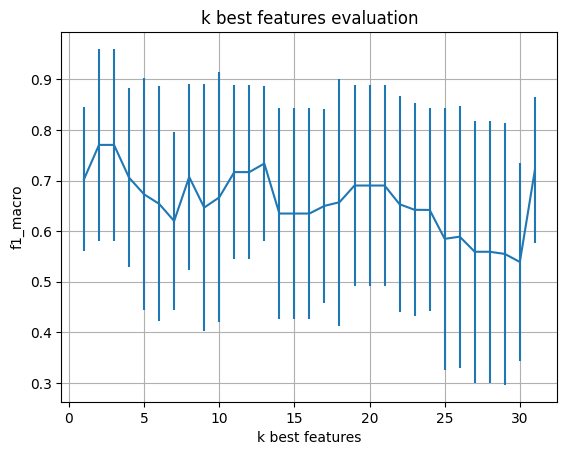

In [61]:
feat_selection(X, y, X_train, y_train, feats_name, selector='SelectKBest')

Best selection : ['num__Age au diagnostic' 'cat__Stade clinique_2' 'cat__PDL1_1.0'
 'cat__PDL1_2.0' 'cat__Type de TTT neoadjuvant_1.0' 'cat__Molecule n°2_2'] 
 k = 6 
 f1_macro = 0.7981318681318681


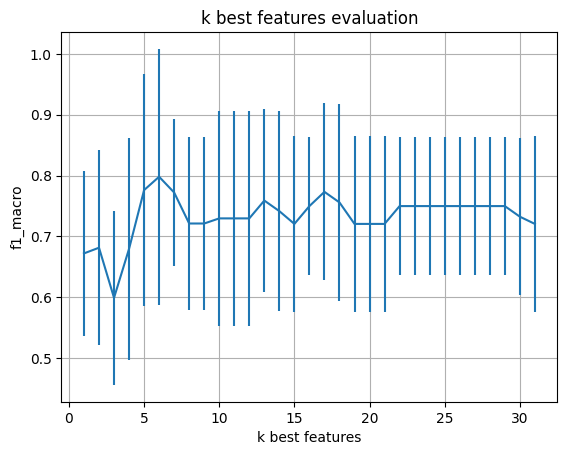

In [62]:
feat_selection(X, y, X_train, y_train, feats_name, selector='RFECV')

In [64]:
from sklearn.linear_model import LogisticRegression

              precision    recall  f1-score   support

           0       0.67      0.40      0.50         5
           1       0.73      0.89      0.80         9

    accuracy                           0.71        14
   macro avg       0.70      0.64      0.65        14
weighted avg       0.71      0.71      0.69        14



In [63]:
def get_label_patient(label, distribution_data, data_light):
    df_light = {row['Patient'].strip(): row.drop('Patient').to_dict() for i, row in data_light.iterrows()}
    labels = [df_light[id_patient(sld_name)][label] for sld_name in distribution_data 
              if id_patient(sld_name) in df_light]
    return labels

In [49]:
distribution_data_filtered = {k: v for k, v in distribution_data.items() if id_patient(k) in data_light['Patient'].values}

## Data analysis

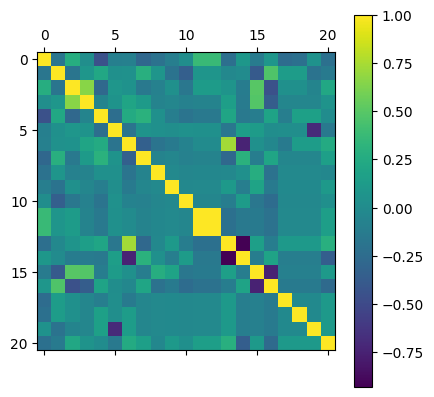

In [413]:
corr_mat = np.corrcoef(X, y, rowvar=False)
plt.matshow(corr_mat)
plt.colorbar()

## Clustering - Optimal Transport

In [260]:
grid = np.linspace(0, 2, 100)
X = np.array([
    dist['kde']['center'](grid) 
    for _, dist in distribution_data_local.items()
])

for row in X:
    row /= row.sum()

X = X.T

Début du clustering...
Convergence atteinte à l'itération 5.


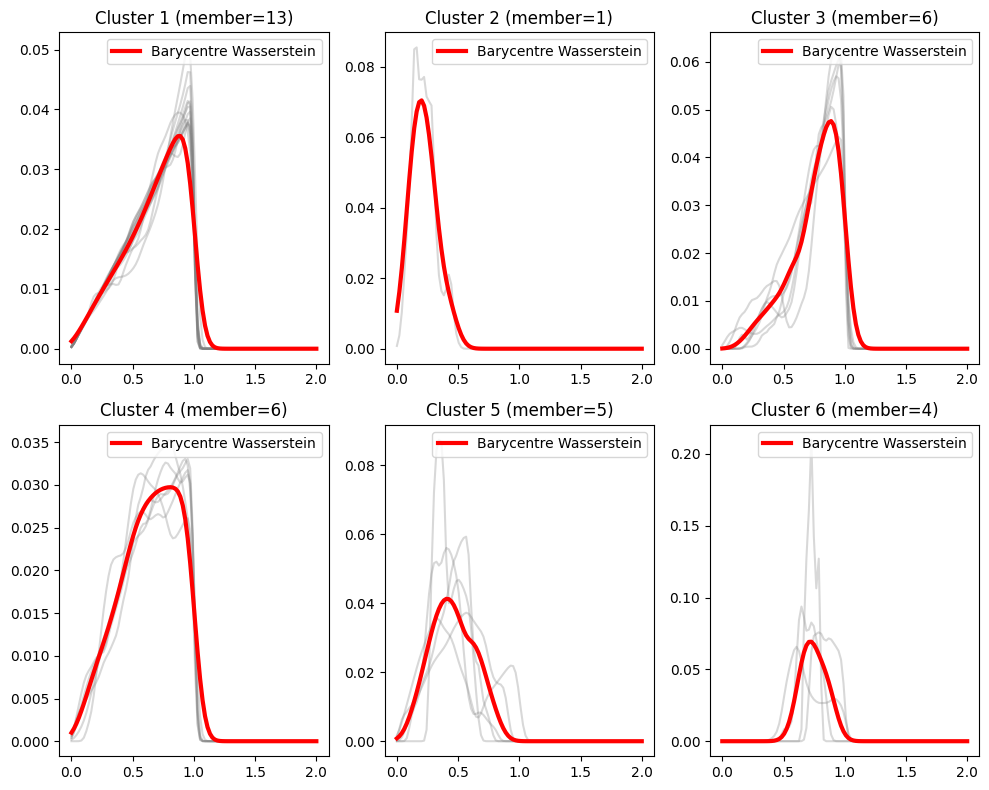

In [ ]:
d, N = X.shape
K = 6                  # Nombre de clusters
max_iter = 50          # Nombre maximum d'itérations
reg = 2e-3             # Paramètre de régularisation entropique (Sinkhorn)
M = ot.dist(grid.reshape((d, 1)), grid.reshape((d, 1)))
M /= np.max(M)
method = 'sinkhorn_log'
# ==========================================
# Algorithme K-Means avec Transport Optimal
# ==========================================
print("Début du clustering...")

init_indices = np.random.choice(N, K, replace=False)
centers = X[:, init_indices].copy()
labels = np.zeros(N)

for iteration in range(max_iter):
    
    # --- ÉTAPE 1 : Assignation ---
    distances = np.zeros((N, K))
    for i in range(N):
        for k in range(K):
            distances[i, k] = ot.sinkhorn2(
                X[:, i], centers[:, k], M, reg, 
                method=method,
            )
            
    new_labels = np.argmin(distances, axis=1)
    
    if np.array_equal(labels, new_labels):
        print(f"Convergence atteinte à l'itération {iteration}.")
        break
    labels = new_labels
    
    # --- ÉTAPE 2 : Mise à jour (Barycentres de Wasserstein) ---
    for k in range(K):
        cluster_data = X[:, labels == k]
        if cluster_data.shape[1] > 0:
            centers[:, k] = ot.bregman.barycenter(
                cluster_data, M, reg,
                method=method
            )

labels_ot_kmeans = labels

# Visualisation
plt.figure(figsize=(10, 8))
cols = math.ceil(math.sqrt(K))
rows = math.ceil(K / cols)
for k in range(K):
    plt.subplot(rows, cols, k+1)
    cluster_data = X[:, labels == k]
    
    # Afficher les distributions du cluster
    for i in range(cluster_data.shape[1]):
        plt.plot(grid, cluster_data[:, i], color='gray', alpha=0.3)
        
    # Afficher le barycentre
    plt.plot(grid, centers[:, k], color='red', linewidth=3, label='Barycentre Wasserstein')
    
    plt.title(f'Cluster {k+1} (member={cluster_data.shape[1]})')
    plt.legend()

plt.tight_layout()
plt.show()

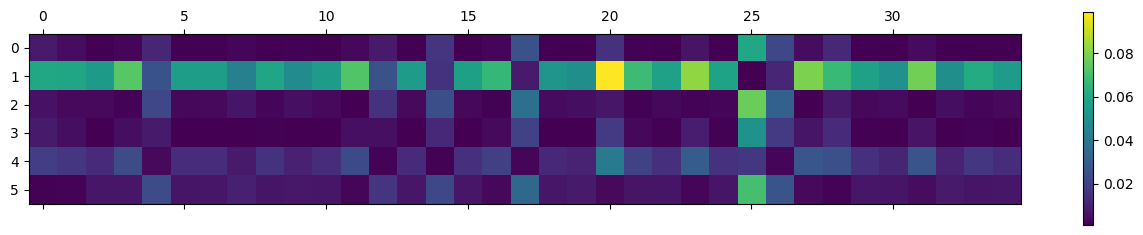

In [262]:
plt.matshow(distances.T)
plt.colorbar()